In [1]:
import pandas as pd
import math

In [2]:
#분석 데이터 불러오기
#분석은 의령군 / 산청군 생활인구, 접근성, 문화공간 현황 분석

per23 = pd.read_csv('23년도 경남 생활인구 데이터.csv', encoding='utf-8')

move23 = pd.read_csv('23년도 경남 접근성 데이터 셋.csv', sep= '\t',encoding='cp949')

In [3]:
per23 = per23[per23['시군구명'].isin(['의령군','산청군'])]
move23 = move23[move23['시군구명'].isin(['의령군','산청군'])]

In [4]:
men_cnt23 = [int(col.replace(',','')) for col in per23['남']]
w_cnt23 = [int(col.replace(',','')) for col in per23['여']]
per23['남'] = men_cnt23
per23['여'] = w_cnt23

In [5]:
per23

,시군구명,접근성 변수명,남,여
28,의령군,세대인구_외국인,625,259
29,의령군,세대인구_성별,12668,12807
30,의령군,거주인구_총인구,13293,13066
31,의령군,연령별_100세 이상인구,5,12
32,의령군,연령별_10대미만 인구,459,13034
33,의령군,연령별_10대인구,719,629
34,의령군,연령별_20대인구,881,580
35,의령군,연령별_30대인구,787,713
36,의령군,연령별_40대인구,1365,1056
37,의령군,연령별_50대인구,2405,1884


In [6]:
#의령 / 산청 데이터나누기

의령인구23 = per23[per23['시군구명']=='의령군']
의령인구23

산청인구23 = per23[per23['시군구명']=='산청군']
산청인구23

의령인구23

,시군구명,접근성 변수명,남,여
28,의령군,세대인구_외국인,625,259
29,의령군,세대인구_성별,12668,12807
30,의령군,거주인구_총인구,13293,13066
31,의령군,연령별_100세 이상인구,5,12
32,의령군,연령별_10대미만 인구,459,13034
33,의령군,연령별_10대인구,719,629
34,의령군,연령별_20대인구,881,580
35,의령군,연령별_30대인구,787,713
36,의령군,연령별_40대인구,1365,1056
37,의령군,연령별_50대인구,2405,1884


In [8]:
의령거주인구23 = 의령인구23.iloc[0:3]

의령거주인구23['합계'] = 의령거주인구23[['남','여']].sum(axis = 1)
의령거주인구23

C:\Users\user\AppData\Local\Temp\ipykernel_13756\3986089398.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  의령거주인구23['합계'] = 의령거주인구23[['남','여']].sum(axis = 1)


,시군구명,접근성 변수명,남,여,합계
28,의령군,세대인구_외국인,625,259,884
29,의령군,세대인구_성별,12668,12807,25475
30,의령군,거주인구_총인구,13293,13066,26359


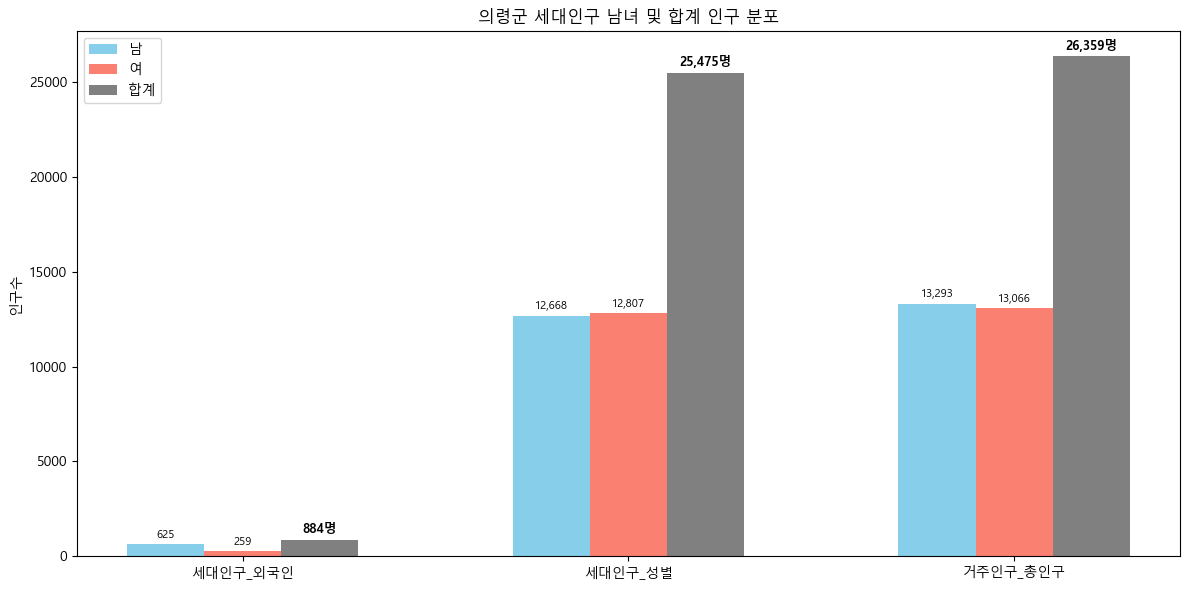

In [10]:
#의령군 23년도 거주인구 분석

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# x축 라벨
x_label  = 의령거주인구23['접근성 변수명']
men = 의령거주인구23['남']
women = 의령거주인구23['여']
total = 의령거주인구23['합계']

# x 위치 설정
x = np.arange(len(x_label)) * 1.5
bar_width = 0.3

fig, ax = plt.subplots(figsize=(12, 6))

# 막대그래프 생성
bar_men = ax.bar(x - bar_width, men, width=bar_width, label='남', color='skyblue')
bar_women = ax.bar(x, women, width=bar_width, label='여', color='salmon')
bar_total = ax.bar(x + bar_width, total, width=bar_width, label='합계', color='gray')

# 남 텍스트
for bar in bar_men:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 200, f'{height:,}', ha='center', va='bottom', fontsize=8)

# 여 텍스트
for bar in bar_women:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 200, f'{height:,}', ha='center', va='bottom', fontsize=8)

# 합계 텍스트
for bar in bar_total:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 200, f'{height:,}명', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 축, 라벨, 범례
ax.set_xticks(x)
ax.set_xticklabels(x_label, rotation=0)
ax.set_ylabel("인구수")
ax.set_title("의령군 세대인구 남녀 및 합계 인구 분포")
ax.legend()

plt.tight_layout()
plt.show()


In [11]:
의령연령별23 = 의령인구23[
    (의령인구23["접근성 변수명"].str.contains("연령별")) &
    (~의령인구23["접근성 변수명"].str.contains("총인구|성별"))
]


의령연령별23["연령순서"] = (
    의령연령별23["접근성 변수명"]
    .str.extract(r'(\d+)', expand=False) 
    .fillna("1000") 
    .astype(int)
)

# 연령순서 기준으로 정렬
의령연령별23 = 의령연령별23.sort_values("연령순서").drop(columns="연령순서")


의령연령별23['합계'] = 의령연령별23[['남','여']].sum(axis = 1)
의령연령별23

C:\Users\user\AppData\Local\Temp\ipykernel_13756\814830768.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  의령연령별23["연령순서"] = (


,시군구명,접근성 변수명,남,여,합계
32,의령군,연령별_10대미만 인구,459,13034,13493
33,의령군,연령별_10대인구,719,629,1348
34,의령군,연령별_20대인구,881,580,1461
35,의령군,연령별_30대인구,787,713,1500
36,의령군,연령별_40대인구,1365,1056,2421
37,의령군,연령별_50대인구,2405,1884,4289
38,의령군,연령별_60대인구,3294,2803,6097
39,의령군,연령별_70대인구,1750,2065,3815
40,의령군,연령별_80대인구,897,2228,3125
41,의령군,연령별_90대인구,106,458,564


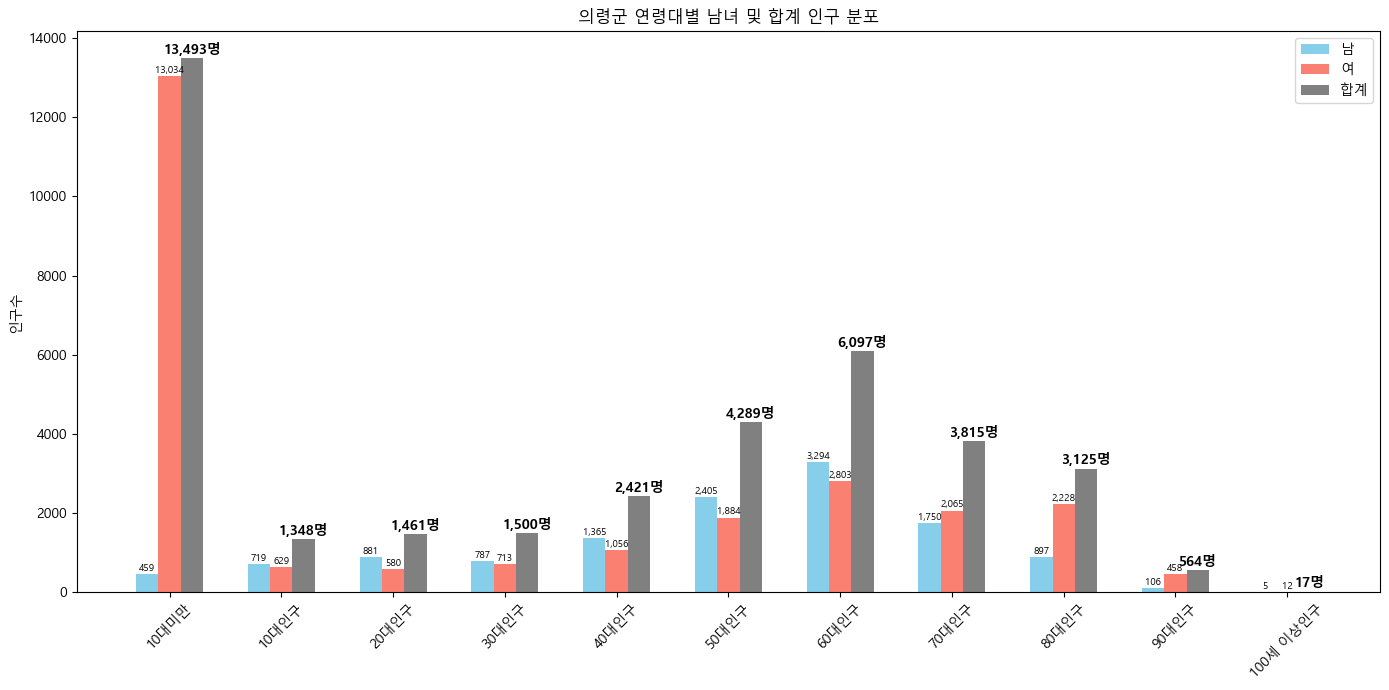

의령군 총인구 수 : 38,130명


In [12]:
#의령군 22년도 생활인구 분석
#의령군 연령대별 인구

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'

import matplotlib.pyplot as plt
import numpy as np

# 데이터 준비
x_labels = 의령연령별23["접근성 변수명"].str.replace("연령별_", "").str.replace(" 인구", "").str.strip()
men = 의령연령별23["남"]
women = 의령연령별23["여"]
total = 의령연령별23["합계"]

# X 위치 및 막대 너비 설정
x = np.arange(len(x_labels)) * 2  # 간격 넓게
bar_width = 0.4

fig, ax = plt.subplots(figsize=(14, 7))

# 막대그래프: 남, 여, 합계
bars_men = ax.bar(x - bar_width, men, width=bar_width, label="남", color="skyblue")
bars_women = ax.bar(x, women, width=bar_width, label="여", color="salmon")
bars_total = ax.bar(x + bar_width, total, width=bar_width, label="합계", color="gray")

# 텍스트 라벨: 남
for bar in bars_men:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 30, f'{height:,}', ha='center', va='bottom', fontsize=7)

# 텍스트 라벨: 여
for bar in bars_women:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 30, f'{height:,}', ha='center', va='bottom', fontsize=7)

# 텍스트 라벨: 합계
for bar in bars_total:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 30, f'{height:,}명', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 축, 라벨, 범례
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_ylabel("인구수")
ax.set_title("의령군 연령대별 남녀 및 합계 인구 분포")
ax.legend()

plt.tight_layout()
plt.show()


print(f'의령군 총인구 수 : {의령연령별23['합계'].sum():,}명')

In [13]:
산청거주인구23 = 산청인구23.iloc[0:3]

산청거주인구23['합계'] = 산청거주인구23[['남','여']].sum(axis = 1)
산청거주인구23

C:\Users\user\AppData\Local\Temp\ipykernel_13756\468194967.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  산청거주인구23['합계'] = 산청거주인구23[['남','여']].sum(axis = 1)


,시군구명,접근성 변수명,남,여,합계
42,산청군,세대인구_외국인,385,484,869
43,산청군,세대인구_성별,16758,16994,33752
44,산청군,거주인구_총인구,17143,17478,34621


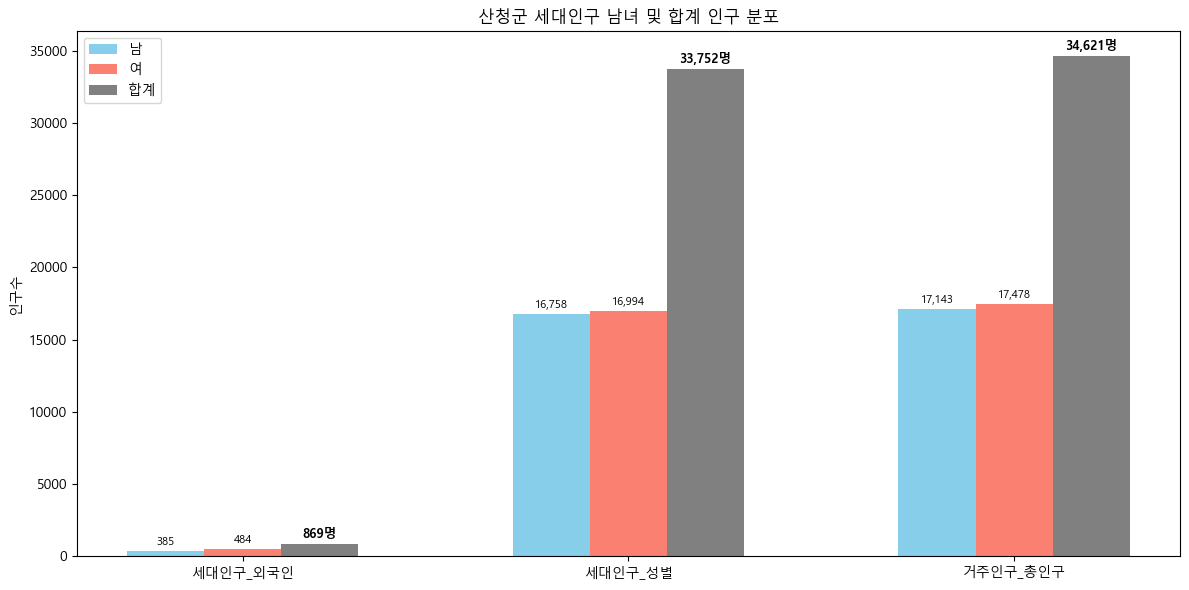

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# x축 라벨
x_label  = 산청거주인구23['접근성 변수명']
men = 산청거주인구23['남']
women = 산청거주인구23['여']
total = 산청거주인구23['합계']

# x 위치 설정
x = np.arange(len(x_label)) * 1.5
bar_width = 0.3

fig, ax = plt.subplots(figsize=(12, 6))

# 막대그래프 생성
bar_men = ax.bar(x - bar_width, men, width=bar_width, label='남', color='skyblue')
bar_women = ax.bar(x, women, width=bar_width, label='여', color='salmon')
bar_total = ax.bar(x + bar_width, total, width=bar_width, label='합계', color='gray')

# 남 텍스트
for bar in bar_men:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 200, f'{height:,}', ha='center', va='bottom', fontsize=8)

# 여 텍스트
for bar in bar_women:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 200, f'{height:,}', ha='center', va='bottom', fontsize=8)

# 합계 텍스트
for bar in bar_total:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 200, f'{height:,}명', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 축, 라벨, 범례
ax.set_xticks(x)
ax.set_xticklabels(x_label, rotation=0)
ax.set_ylabel("인구수")
ax.set_title("산청군 세대인구 남녀 및 합계 인구 분포")
ax.legend()

plt.tight_layout()
plt.show()

In [15]:
산청연령별23 = 산청인구23[
    (산청인구23["접근성 변수명"].str.contains("연령별")) &
    (~산청인구23["접근성 변수명"].str.contains("총인구|성별"))
]

산청연령별23["연령순서"] = (
    산청연령별23["접근성 변수명"]
    .str.extract(r'(\d+)', expand=False) 
    .fillna("1000") 
    .astype(int)
)

# 연령순서 기준으로 정렬
산청연령별23 = 산청연령별23.sort_values("연령순서").drop(columns="연령순서")

산청연령별23['합계'] = 산청연령별23[['남','여']].sum(axis = 1)
산청연령별23

C:\Users\user\AppData\Local\Temp\ipykernel_13756\3550838727.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  산청연령별23["연령순서"] = (


,시군구명,접근성 변수명,남,여,합계
46,산청군,연령별_10대미만 인구,965,467,1432
47,산청군,연령별_10대인구,1031,864,1895
48,산청군,연령별_20대인구,1151,829,1980
49,산청군,연령별_30대인구,966,783,1749
50,산청군,연령별_40대인구,1597,1355,2952
51,산청군,연령별_50대인구,3339,2740,6079
52,산청군,연령별_60대인구,4330,3904,8234
53,산청군,연령별_70대인구,2520,2740,5260
54,산청군,연령별_80대인구,1216,2734,3950
55,산청군,연령별_90대인구,108,563,671


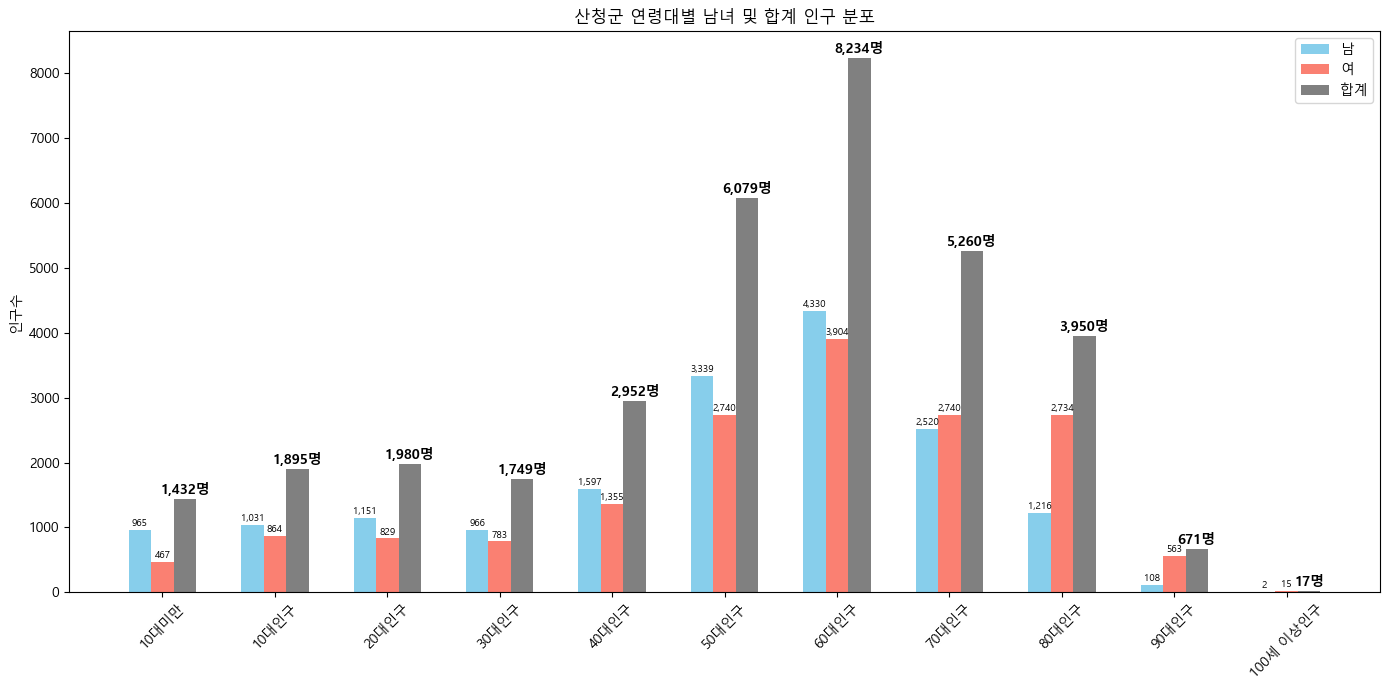

산청군 총인구 수 : 34,219명


In [16]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'

import matplotlib.pyplot as plt
import numpy as np

# 데이터 준비
x_labels = 산청연령별23["접근성 변수명"].str.replace("연령별_", "").str.replace(" 인구", "").str.strip()
men = 산청연령별23["남"]
women = 산청연령별23["여"]
total = 산청연령별23["합계"]

# X 위치 및 막대 너비 설정
x = np.arange(len(x_labels)) * 2  # 간격 넓게
bar_width = 0.4

fig, ax = plt.subplots(figsize=(14, 7))

# 막대그래프: 남, 여, 합계
bars_men = ax.bar(x - bar_width, men, width=bar_width, label="남", color="skyblue")
bars_women = ax.bar(x, women, width=bar_width, label="여", color="salmon")
bars_total = ax.bar(x + bar_width, total, width=bar_width, label="합계", color="gray")

# 텍스트 라벨: 남
for bar in bars_men:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 30, f'{height:,}', ha='center', va='bottom', fontsize=7)

# 텍스트 라벨: 여
for bar in bars_women:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 30, f'{height:,}', ha='center', va='bottom', fontsize=7)

# 텍스트 라벨: 합계
for bar in bars_total:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 30, f'{height:,}명', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 축, 라벨, 범례
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_ylabel("인구수")
ax.set_title("산청군 연령대별 남녀 및 합계 인구 분포")
ax.legend()

plt.tight_layout()
plt.show()

print(f'산청군 총인구 수 : {산청연령별23['합계'].sum():,}명')

In [17]:
#접근성 현황분석

move23

,시군구명,접근성 변수명,위도,경도
6484,산청군,버스정류장_외부마을,35.416752,127.897085
6485,산청군,버스정류장_향양마을,35.410898,127.832699
6486,산청군,버스정류장_모례,35.463494,127.969346
6487,산청군,버스정류장_구평,35.641400,127.859451
6488,산청군,버스정류장_생초시외버스정류소,35.492044,127.832781
...,...,...,...,...
6908,의령군,주차장_백산마을 주차장,35.431821,128.377777
6909,의령군,주차장_사현마을 주차장,35.474022,128.264453
6910,의령군,주차장_성당마을 주차장,35.363591,128.389512
6911,의령군,주차장_오천마을 주차장,35.387620,128.396221


In [18]:
산청23 = move23[move23['시군구명']=='산청군']

의령23 = move23[move23['시군구명']=='의령군']

print(move23['시군구명'].value_counts())

시군구명
의령군    153
산청군    152
Name: count, dtype: int64


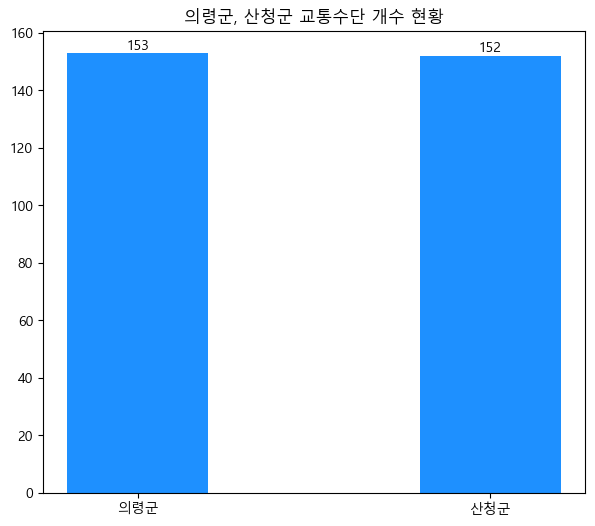

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize = (7,6))
plt.rcParams['font.family']= 'Malgun Gothic'

x = ['의령군','산청군']
y = [153, 152]

plt.bar(x,y,color= 'dodgerblue', width = 0.4)

plt.text(0,154,str(153), ha = 'center', fontsize = 10)
plt.text(1, 153.5, str(152), ha = 'center', fontsize = 10)

plt.title('의령군, 산청군 교통수단 개수 현황')
plt.show()

In [20]:
li = 의령23['접근성 변수명'].to_list()

종류 = []
주소 = []

for i in li:
    i_split = i.split('_')
    종류.append(i_split[0])
    주소.append(i_split[1])


의령23['종류'] = 종류
의령23['주소'] = 주소

의령23 = 의령23.drop('접근성 변수명', axis = 1)

의령23

print(의령23['종류'].value_counts())

종류
주차장      96
버스정류장    57
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_13756\2722470052.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  의령23['종류'] = 종류
C:\Users\user\AppData\Local\Temp\ipykernel_13756\2722470052.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  의령23['주소'] = 주소


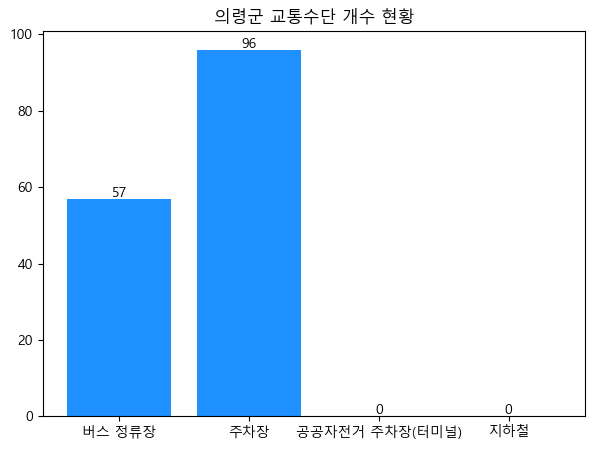

의령군 교통수단 총 개수 : 153


In [21]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.figure(figsize=(7,5))

x = ['버스 정류장', '주차장', '공공자전거 주차장(터미널)', '지하철']
y = [57, 96, 0, 0]

plt.bar(x,y, color = 'dodgerblue')

plt.text(0,57.5,str(57), ha = 'center', fontsize = 10)
plt.text(1, 96.5, str(96), ha = 'center', fontsize = 10)
plt.text(2, 0.5, str(0), ha = 'center', fontsize = 10)
plt.text(3, 0.5, str(0), ha = 'center', fontsize = 10)

plt.title('의령군 교통수단 개수 현황')
plt.show()

print(f'의령군 교통수단 총 개수 : {sum(y)}')

In [22]:
산청23


li = 산청23['접근성 변수명'].to_list()

종류 = []
주소 = []

for i in li:
    i_split = i.split('_')
    종류.append(i_split[0])
    주소.append(i_split[1])


산청23['종류'] = 종류
산청23['주소'] = 주소

산청23 = 산청23.drop('접근성 변수명', axis = 1)

산청23

print(산청23['종류'].value_counts())

종류
버스정류장    130
주차장       22
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_13756\1542983545.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  산청23['종류'] = 종류
C:\Users\user\AppData\Local\Temp\ipykernel_13756\1542983545.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  산청23['주소'] = 주소


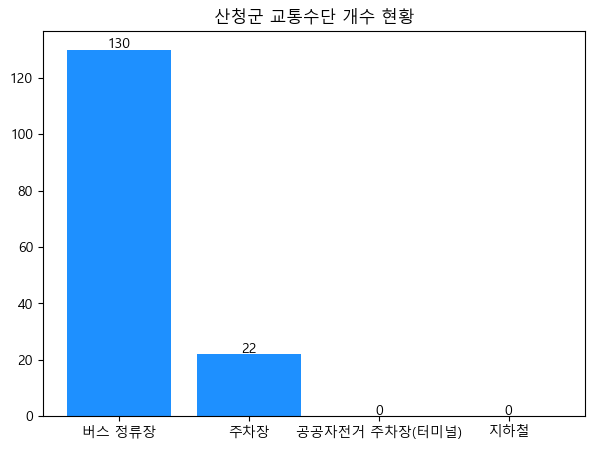

산청군 교통수단 총 개수 : 152


In [23]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.figure(figsize=(7,5))

x = ['버스 정류장', '주차장', '공공자전거 주차장(터미널)', '지하철']
y = [130, 22, 0, 0]

plt.bar(x,y, color = 'dodgerblue')

plt.text(0,130.5,str(130), ha = 'center', fontsize = 10)
plt.text(1, 22.5, str(22), ha = 'center', fontsize = 10)
plt.text(2, 0.5, str(0), ha = 'center', fontsize = 10)
plt.text(3, 0.5, str(0), ha = 'center', fontsize = 10)

plt.title('산청군 교통수단 개수 현황')
plt.show()

print(f'산청군 교통수단 총 개수 : {sum(y)}')

In [32]:
cul = pd.read_csv('geocoding_culture_data.csv',encoding = 'utf-8')

cul

,Unnamed: 0,시군구,소재지,Latitude,Longitude,구분
0,2,산청군,산청군 금서면 친환경로2631번길 12,35.420126,127.872855,문화예술회관
1,7,의령군,의령군 의령읍 의병로24길 31-1,35.317694,128.264840,문화예술회관
2,10,김해시,김해시 김해대로 2062 (내동),35.242477,128.863187,문화예술회관
3,13,창원시,창원시 진해구 진해대로 325 (태백동),35.169833,128.666084,문화예술회관
4,14,창원시,창원시 마산회원구 삼호로 135,35.225855,128.577258,문화예술회관
...,...,...,...,...,...,...
142,7,창원시,창원시 진해구 중원로 1,35.144006,128.658285,박물관
143,17,창원시,창원시 진해구 중원동로 52 (제황산동),35.148911,128.663991,박물관
144,20,김해시,김해시 인제로 197 (어방동),35.250387,128.901177,박물관
145,21,창원시,창원시 의창구 퇴촌로 92 (퇴촌동),35.250146,128.696122,박물관


In [33]:
groups = cul.groupby('시군구')['구분']

for i,j in groups:
    print(f'{i}의 문화시설 개수 : {len(j)}')

김해시의 문화시설 개수 : 57
산청군의 문화시설 개수 : 8
의령군의 문화시설 개수 : 3
창원시의 문화시설 개수 : 79


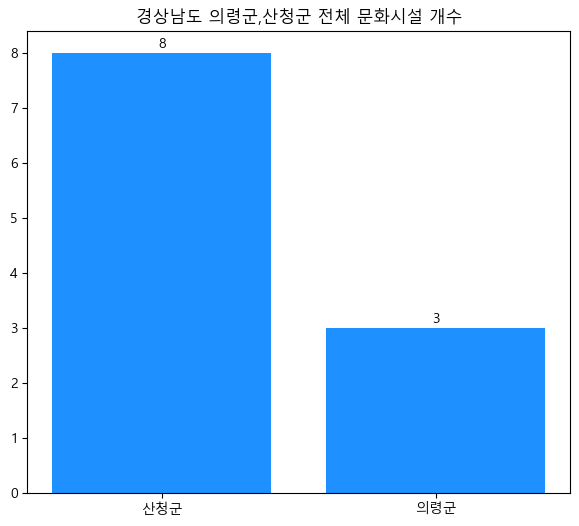

In [78]:
#시군구별 문화시설 개수 현황그래프

import matplotlib.pyplot as plt

plt.figure(figsize = (7,6))
plt.rcParams['font.family'] = 'Malgun gothic'

x = ['산청군', '의령군']
y = [8, 3]

plt.bar(x,y, color= 'dodgerblue')


plt.text(0, 8.1, str(8), ha = 'center', fontsize = 10)
plt.text(1, 3.1, str(3), ha = 'center', fontsize = 10)

plt.title('경상남도 의령군,산청군 전체 문화시설 개수')


plt.show()

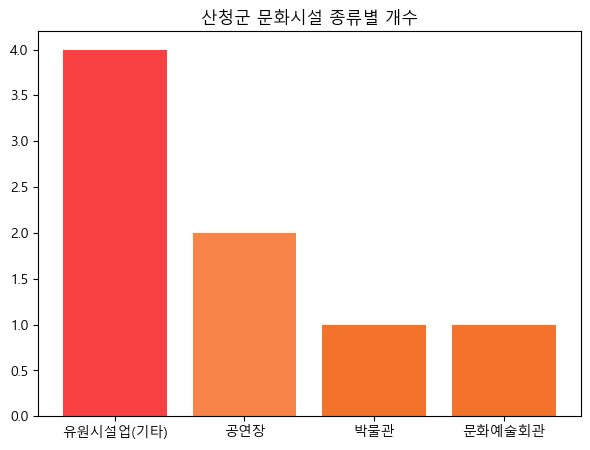

In [219]:
import matplotlib.pyplot as plt

plt.figure(figsize = (7,5))
plt.rcParams['font.family'] = 'Malgun gothic'

x = ['유원시설업(기타)','공연장','박물관','문화예술회관']
y = [4,2,1,1]

# 4가지 색상: 머스터드 제외, 대신 레드와 오렌지 계열 3개 조합 + 살짝 연한 오렌지 추가
colors = [
    "#F94144",  # 선명한 레드
    "#F9844A",  # 살짝 연한 오렌지
    "#F3722C",  # 진한 오렌지
    "#F3722C"   # 진한 오렌지 (마지막 2개가 같음, 필요하면 다른 색으로 바꿔도 됨)
]

plt.bar(x, y, color=colors)

# # 값 텍스트 (색상 맞춤)
# for i, val in enumerate(y):
#     plt.text(i, val + 0.1, str(val), ha='center', fontsize=10, color=colors[i])

plt.title('산청군 문화시설 종류별 개수')

plt.show()

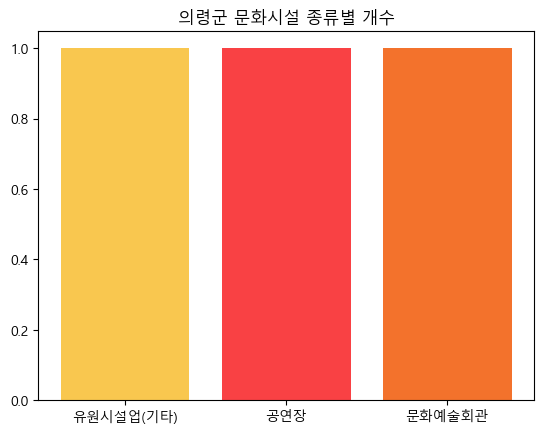

In [217]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun gothic'

x = ['유원시설업(기타)','공연장','문화예술회관']
y = [1,1,1]

# 지정한 3가지 색상
colors = ["#F9C74F",  # 머스터드 옐로우
          "#F94144",  # 선명한 레드
          "#F3722C"]  # 진한 오렌지

plt.bar(x, y, color=colors)

# 막대 위에 값 표시 (텍스트도 각각 같은 색상으로 맞춤)
# for i, val in enumerate(y):
#     plt.text(i, val + 0.05, str(val), ha='center', fontsize=10, color=colors[i])

plt.title('의령군 문화시설 종류별 개수')

plt.show()

In [56]:
의령문화시설 = cul[cul['시군구']=='의령군']

의령문화시설

,Unnamed: 0,시군구,소재지,Latitude,Longitude,구분
1,7,의령군,의령군 의령읍 의병로24길 31-1,35.317694,128.264840,문화예술회관
20,36,의령군,경상남도 의령군 의령읍 동동리 877-24번지,35.318236,128.265268,공연장
67,89,의령군,경상남도 의령군 의령읍 서동리 484-5번지,35.319838,128.260192,유원시설업(기타)


In [ ]:
#문화공간별 접근성 알이보기

In [43]:
!pip install folium

  Using cached folium-0.19.6-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached branca-0.8.1-py3-none-any.whl.metadata (1.5 kB)
  Using cached xyzservices-2025.4.0-py3-none-any.whl.metadata (4.3 kB)
Using cached folium-0.19.6-py2.py3-none-any.whl (112 kB)
Using cached branca-0.8.1-py3-none-any.whl (26 kB)
Using cached xyzservices-2025.4.0-py3-none-any.whl (90 kB)



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [160]:
import folium

#의령군지도 불러오기
m = folium.Map(location = [35.3221896, 128.261658],
            zoom_start = 15,
              titles = 'Stamen Terrain')

m

In [104]:
의령문화시설

,Unnamed: 0,시군구,소재지,Latitude,Longitude,구분
1,7,의령군,의령군 의령읍 의병로24길 31-1,35.317694,128.264840,문화예술회관
20,36,의령군,경상남도 의령군 의령읍 동동리 877-24번지,35.318236,128.265268,공연장
67,89,의령군,경상남도 의령군 의령읍 서동리 484-5번지,35.319838,128.260192,유원시설업(기타)


In [171]:
#지도위에 의령군 문화시설 표시하기

for i,row in 의령문화시설.iterrows():
    위도 = row['Latitude']
    경도 = row['Longitude']
    종류 = row['구분']

    folium.Marker([위도,경도],icon = folium.Icon(color='red', icon = 'music',icon_color = 'white')).add_to(m)

    folium.Circle(location=[위도, 경도],
        radius=500,  # 미터 단위
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.2
    ).add_to(m)

m

In [112]:
의령23

,시군구명,위도,경도,종류,주소
6614,의령군,35.323882,128.243071,버스정류장,가례
6615,의령군,35.461935,128.251115,버스정류장,걔현2구
6616,의령군,35.431759,128.268696,버스정류장,계현입구
6617,의령군,35.420201,128.286022,버스정류장,구송산
6618,의령군,35.399975,128.278603,버스정류장,구오목
...,...,...,...,...,...
6908,의령군,35.431821,128.377777,주차장,백산마을 주차장
6909,의령군,35.474022,128.264453,주차장,사현마을 주차장
6910,의령군,35.363591,128.389512,주차장,성당마을 주차장
6911,의령군,35.387620,128.396221,주차장,오천마을 주차장


In [120]:
print(의령23['종류'].value_counts())

종류
주차장      96
버스정류장    57
Name: count, dtype: int64


In [162]:
#의령군 교통접근성 표시하기


의령23

for i,row in 의령23.iterrows():
    위도 = row['위도']
    경도 = row['경도']
    종류 = row['종류']
    
    if 종류 == '주차장':
        folium.Marker([위도,경도],icon = folium.Icon(color='blue', icon = 'road', icon_color = 'white')).add_to(m)
    elif 종류 == '버스정류장':
        folium.Marker([위도,경도],icon = folium.Icon(color='blue', icon = 'road',icon_color = 'white')).add_to(m)
    
    

m

In [163]:
import folium


s_m = folium.Map(location = [35.4155885,127.8734981], zoom_strat = 20,  titles = 'Stamen Terrain')

s_m

In [166]:
산청문화시설 = cul[cul['시군구']=='산청군']
산청문화시설

,Unnamed: 0,시군구,소재지,Latitude,Longitude,구분
0,2,산청군,산청군 금서면 친환경로2631번길 12,35.420126,127.872855,문화예술회관
21,44,산청군,경상남도 산청군 금서면 매촌리 80번지,35.418925,127.859684,공연장
22,45,산청군,경상남도 산청군 금서면 매촌리 80번지,35.418925,127.859684,공연장
68,94,산청군,경상남도 산청군 신등면 모례리 756-5번지 숲속정원관광농원,35.399077,127.971100,유원시설업(기타)
117,275,산청군,경상남도 산청군 시천면 반천리 산 65 서지관광농원,35.230164,127.790150,유원시설업(기타)
132,327,산청군,경상남도 산청군 시천면 동당리 577 덕산관광휴양지,35.272704,127.778289,유원시설업(기타)
137,345,산청군,경상남도 산청군 시천면 사리 258-8,35.266981,127.856504,유원시설업(기타)
146,22,산청군,산청군 금서면 동의보감로 555,35.444994,127.827103,박물관


In [167]:
#산청군 문화시설 위치 지도 표시

for i,row in 산청문화시설.iterrows():
    위도 = row['Latitude']
    경도 = row['Longitude']
    종류 = row['구분']

    folium.Marker([위도,경도],icon = folium.Icon(color='red', icon = 'music',icon_color = 'white')).add_to(s_m)


s_m

In [168]:
#산청군 교통접근성 지도표시



for i,row in 산청문화시설.iterrows():
    위도 = row['Latitude']
    경도 = row['Longitude']
    종류 = row['구분']

    folium.Marker([위도,경도],icon = folium.Icon(color='red', icon = 'music',icon_color = 'white')).add_to(s_m)

       # 반경 500미터 원 추가
    folium.Circle(
        location=[위도, 경도],
        radius=500,  # 미터 단위
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.2
    ).add_to(s_m)



s_m

for i,row in 산청23.iterrows():
    위도 = row['위도']
    경도 = row['경도']
    종류 = row['종류']

    folium.Marker([위도,경도], icon = folium.Icon(color='blue', icon = 'road', icon_color = 'white')).add_to(s_m)

s_m

In [207]:
김해cul = cul[cul['시군구']=='김해시']

culture_cnt = 김해cul.groupby(["시군구", "구분"])['소재지'].count().reset_index()

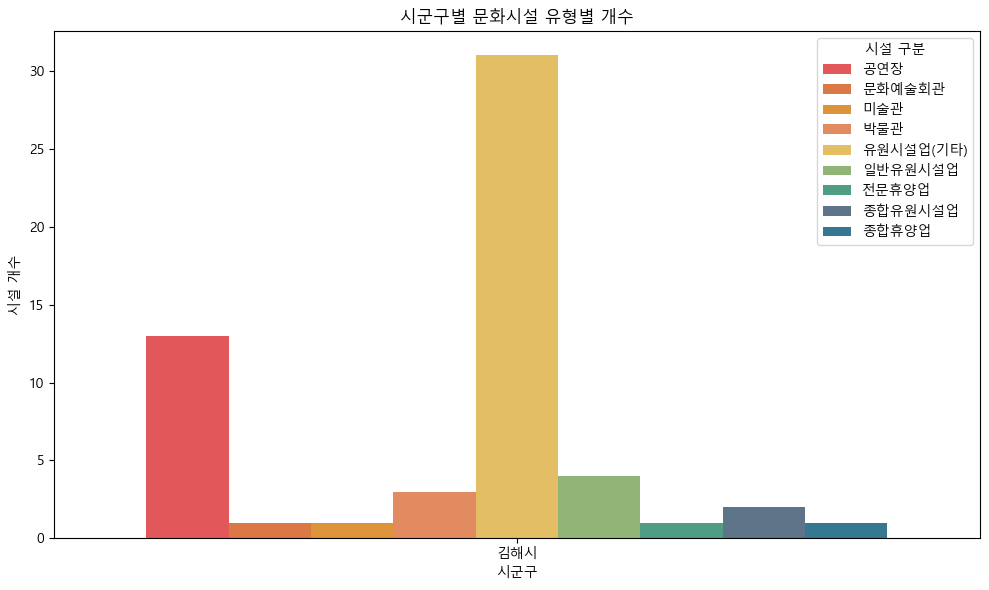

In [215]:
# 그래프

# import packages
import pandas as pd
import numpy as np
# import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
# import folium
# from folium.plugins import MarkerCluster
# from shapely.geometry import Point
# from sklearn.preprocessing import StandardScaler
# from sklearn.cluster import KMeans
# import plotly.express as px
# import networkx as nx
# import os


import matplotlib.pyplot as plt
import seaborn as sns

# 9가지 색상 지정 (앞서 제공한 블루~핑크 계열)
custom_palette = [
    "#F94144",  # 선명한 레드
    "#F3722C",  # 진한 오렌지
    "#F8961E",  # 중간 오렌지
    "#F9844A",  # 살짝 연한 오렌지
    "#F9C74F",  # 머스터드 옐로우
    "#90BE6D",  # 라이트 올리브
    "#43AA8B",  # 민트-그린
    "#577590",  # 블루그레이
    "#277DA1"   # 선명한 블루
]

# 구분 컬럼의 고유값 추출 (정렬 순서에 따라 달라질 수 있음)
unique_types = culture_cnt['구분'].unique()

# 고유값 수에 따라 색상 수 맞추기 (초과/부족할 경우 예외 처리 가능)
palette_dict = {key: custom_palette[i] for i, key in enumerate(unique_types)}

# 그래프 그리기
plt.figure(figsize=(10, 6))
sns.barplot(data=culture_cnt, x='시군구', y='소재지', hue='구분', palette=palette_dict)
plt.title('시군구별 문화시설 유형별 개수')
plt.ylabel('시설 개수')
plt.xlabel('시군구')
plt.legend(title='시설 구분')
plt.tight_layout()
plt.show()
